In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import product

In [2]:
df = pd.read_csv('Air Traffic Data Updated.csv',parse_dates=['Date'],index_col='Date')
df.head()

,domestic passengers,international passenegrs,domestic freight(in tonne),international freight(in tonne),GDP (in dollars),Population,Jet Fuel Price per Gallon,Inflation Rate,Unemployement Rate,Rupees Exchange Rate
Date,,,,,,,,,,
2009-01-01,3288004,885435,20832,11675,1.341888e+12,1225524753,71.75,10.88,7.66,48.70
2009-01-02,3293220,757168,18645,12482,1.341888e+12,1225524753,61.97,10.88,7.66,49.25
2009-01-03,3122400,848046,23046,15359,1.341888e+12,1225524753,65.01,10.88,7.66,51.13
2009-01-04,3266686,861715,21623,14512,1.341888e+12,1225524753,68.55,10.88,7.66,49.97
2009-01-05,3883887,898410,19534,14586,1.341888e+12,1225524753,72.22,10.88,7.66,48.51


In [3]:
def check_stationarity(timeseries):
    print("Results of ADF Test:")
    adf_test = adfuller(timeseries, autolag='AIC')
    df_output = pd.Series(adf_test[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in adf_test[4].items():
        df_output[f'Critical Value ({key})'] = value
    print(df_output)
    
    if adf_test[1] <= 0.05:
        print("Conclusion: The series is stationary.")
    else:
        print("Conclusion: The series is NOT stationary. Differencing may be needed.")

In [4]:
col = df.columns.to_list()
col = col[1:]
for i in col:
    print(f"\nFeature Name : {i}")
    check_stationarity(df[i])


Feature Name : international passenegrs
Results of ADF Test:
Test Statistic                  -1.708559
p-value                          0.426708
#Lags Used                       2.000000
Number of Observations Used    189.000000
Critical Value (1%)             -3.465431
Critical Value (5%)             -2.876957
Critical Value (10%)            -2.574988
dtype: float64
Conclusion: The series is NOT stationary. Differencing may be needed.

Feature Name : domestic freight(in tonne)
Results of ADF Test:
Test Statistic                  -1.093745
p-value                          0.717560
#Lags Used                      14.000000
Number of Observations Used    177.000000
Critical Value (1%)             -3.467845
Critical Value (5%)             -2.878012
Critical Value (10%)            -2.575551
dtype: float64
Conclusion: The series is NOT stationary. Differencing may be needed.

Feature Name : international freight(in tonne)
Results of ADF Test:
Test Statistic                  -2.605316
p-val

**Applying Log Transform**

In [5]:
df_log = df.copy()

numerical_cols = df.select_dtypes(include=np.number).columns

In [6]:
for col in numerical_cols:
    # Add a small constant if there are any zero values (optional, but good practice)
    if (df[col] <= 0).any():
        print(f"Warning: Column '{col}' contains zero or negative values. Using log(x+1) transform.")
        df_log[col] = np.log(df[col] + 1)
    else:
        df_log[col] = np.log(df[col])

In [7]:
print("Original Data (First 5 Rows):")
print(df.head())

Original Data (First 5 Rows):
            domestic passengers  international passenegrs  \
Date                                                        
2009-01-01              3288004                    885435   
2009-01-02              3293220                    757168   
2009-01-03              3122400                    848046   
2009-01-04              3266686                    861715   
2009-01-05              3883887                    898410   

            domestic freight(in tonne)  international freight(in tonne)  \
Date                                                                      
2009-01-01                       20832                            11675   
2009-01-02                       18645                            12482   
2009-01-03                       23046                            15359   
2009-01-04                       21623                            14512   
2009-01-05                       19534                            14586   

            GDP 

In [8]:
print("\nLog-Transformed Data (First 5 Rows):")
print(df_log.head())


Log-Transformed Data (First 5 Rows):
            domestic passengers  international passenegrs  \
Date                                                        
2009-01-01            15.005791                 13.693834   
2009-01-02            15.007376                 13.537340   
2009-01-03            14.954112                 13.650690   
2009-01-04            14.999287                 13.666680   
2009-01-05            15.172347                 13.708382   

            domestic freight(in tonne)  international freight(in tonne)  \
Date                                                                      
2009-01-01                    9.944246                         9.365205   
2009-01-02                    9.833333                         9.432043   
2009-01-03                   10.045247                         9.639457   
2009-01-04                    9.981513                         9.582731   
2009-01-05                    9.879912                         9.587817   

        

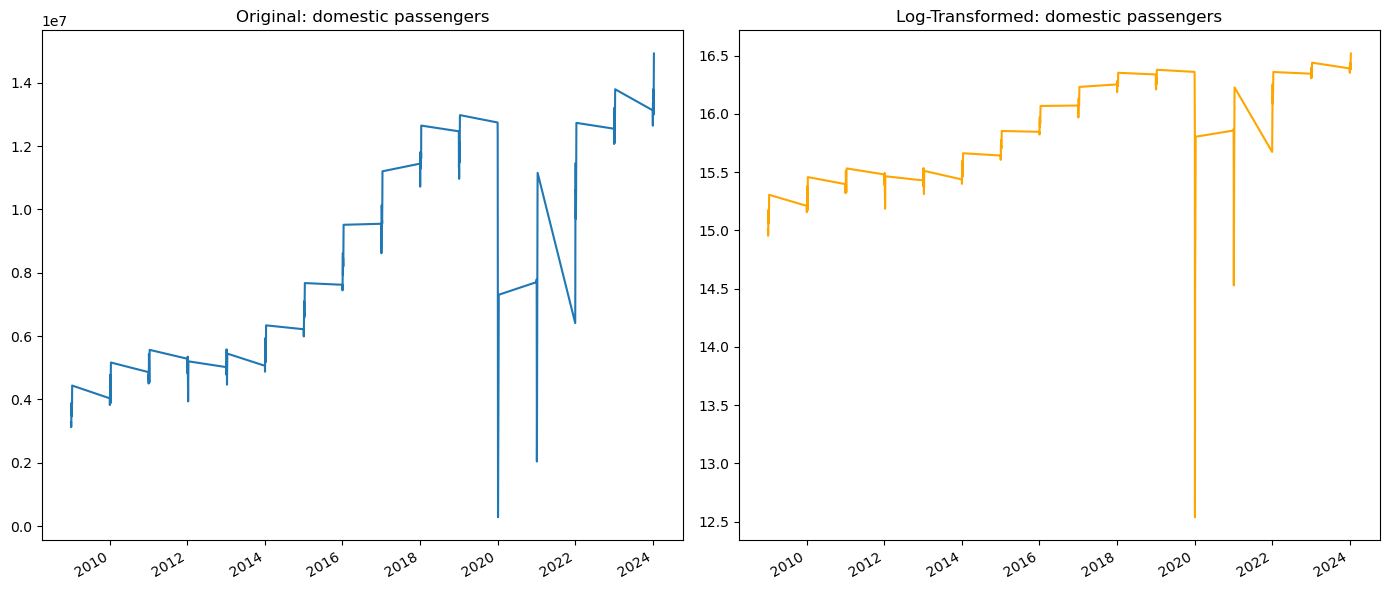

In [9]:
# --- Visualize the Effect (Example on 'domestic passengers') ---
plt.figure(figsize=(14, 6))

# Plot original data
plt.subplot(1, 2, 1)
df['domestic passengers'].plot(title='Original: domestic passengers')
plt.xlabel('')

# Plot log-transformed data
plt.subplot(1, 2, 2)
df_log['domestic passengers'].plot(title='Log-Transformed: domestic passengers', color='orange')
plt.xlabel('')

plt.tight_layout()
plt.show()

**Differencing for Stationarity**

In [10]:
# Assuming monthly data, m=12
m = 12
col = df_log.columns.to_list()
col = col[1:]
col.remove('Population')

for i in col:
    #Seasonal differencing (m=12)
    df_log[i] = df_log[i].diff(periods=m)



In [11]:
# Check stationarity of the differenced data
# You'll need to drop the NaN values created by differencing
print("\nChecking stationarity after differencing...")
for i in col:
    print(f"Feature Name : {i}\n")
    check_stationarity(df[i].dropna())


Checking stationarity after differencing...
Feature Name : international passenegrs

Results of ADF Test:
Test Statistic                  -1.708559
p-value                          0.426708
#Lags Used                       2.000000
Number of Observations Used    189.000000
Critical Value (1%)             -3.465431
Critical Value (5%)             -2.876957
Critical Value (10%)            -2.574988
dtype: float64
Conclusion: The series is NOT stationary. Differencing may be needed.
Feature Name : domestic freight(in tonne)

Results of ADF Test:
Test Statistic                  -1.093745
p-value                          0.717560
#Lags Used                      14.000000
Number of Observations Used    177.000000
Critical Value (1%)             -3.467845
Critical Value (5%)             -2.878012
Critical Value (10%)            -2.575551
dtype: float64
Conclusion: The series is NOT stationary. Differencing may be needed.
Feature Name : international freight(in tonne)

Results of ADF Test:
Te